# Chapter 9. BERT 회귀 — 첫 파인튜닝, 첫 `Trainer`

**목표**: Phase 0의 별점 회귀(Ch 2)를 *DistilBERT 파인튜닝* 으로 다시 풉니다. sklearn `LinearRegression` 이 1초 만에 풀던 문제를, BERT는 GPU에서 수 분간 학습합니다. `Trainer` 가 처음 등장하고, 우리가 sklearn의 `fit()` 대신 *학습 과정 전체* 를 명시적으로 통제하기 시작합니다.

**환경**: Google Colab **T4 GPU 필수** (런타임 → 런타임 유형 변경 → T4 GPU). CPU에서도 동작은 하지만 학습이 한 시간 가까이 걸립니다.

**예상 소요 시간**: 약 10-15분 (T4 GPU 기준, 모델 다운로드 + 2 에폭 학습 + 평가)

---

## 학습 흐름

1. 🚀 **실습**: 데이터 준비 (Ch 8 패턴) → 모델 로드 → `Trainer` + `TrainingArguments` 한 묶음으로 학습
2. 🔬 **해부**: 학습 중·후 GPU 메모리(VRAM) 변화, `Trainer` 가 내부에서 하는 일, sklearn(Ch 2) 결과와 직접 비교
3. 🛠️ **변형**: 평가 지표 (`compute_metrics`) 직접 정의, 예측 분포 시각화

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Activation | Loss |
|---|---|---|---|---|---|---|
| 2 | `LinearRegression()` | `TfidfVectorizer()` | Yelp (별점 1-5) | (1차원) | 없음 | `MSELoss` |
| 7-8 | DistilBERT (추론·데이터 파이프라인) | `AutoTokenizer.from_pretrained(...)` | Yelp / 영어 예시 | 사전학습 헤드 | softmax | — |
| **9 ← 여기** | **DistilBERT 파인튜닝** | `AutoTokenizer.from_pretrained(...)` | Yelp (별점 1-5, Ch 2와 동일) | **`Linear(H, 1)`** | 없음 | **`MSELoss`** |

전체 챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

## 🔄 변경점 (Diff from Ch 8)

| 축 | Ch 8 | Ch 9 |
|---|---|---|
| 모델 | 모델 로드 없음 | **`AutoModelForSequenceClassification` (`num_labels=1`, `problem_type="regression"`)** |
| 학습 | 없음 | **있음** — Trainer.train() |
| Loss | — | **`MSELoss`** (Ch 2와 같은 식, 최소화 방식만 SGD로 바뀜) |
| 데이터 | Yelp 토크나이저 옵션 실험 | Yelp 4,000 학습 + 1,000 평가 (별점 1-5 float 라벨) |
| GPU | 옵션 | **필수** — fp16, 옵티마이저+gradient가 VRAM에 추가 |
| 작업 시간 | 즉시 | **수 분** (T4에서 ~5-8분 학습) |

**핵심 변화**: 같은 MSELoss이지만 *어떻게 최소화하느냐* 가 다릅니다.

- Ch 2 `LinearRegression`: 정규방정식으로 *한 번에* 닫힌 해 도출. 1초 미만.
- Ch 9 BERT: SGD/Adam으로 *수천 번 step* 을 밟으며 점진적 최소화. fp16, 옵티마이저 모멘텀, gradient accumulation 등 도구가 한꺼번에 등장.

Ch 6 끝의 "sklearn vs HuggingFace 미리보기" 표가 이번 챕터에서 실제 코드로 펼쳐집니다.

## 📐 Loss 노트 — `MSELoss` 그대로, 최소화 방식만 바뀜

수식은 Ch 2와 동일합니다.

$$L = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat y_i)^2$$

다른 점은 *어떻게 이 $L$을 최소화하느냐* 입니다.

| 항목 | Ch 2 (`LinearRegression`) | Ch 9 (BERT) |
|---|---|---|
| 최소화 방법 | 정규방정식 $w = (X^\top X)^{-1} X^\top y$ — 한 번에 닫힌 해 | Adam optimizer — gradient descent step을 수천 번 |
| 학습 시간 | 1초 미만 | T4에서 5-8분 |
| 결정성 | 입력이 같으면 가중치가 정확히 같음 | random seed·batch 순서에 따라 매번 미세 차이 |
| 왜 BERT를 쓰나 | 단어 독립 가정의 한계 (`"not bad"` ≠ `"bad"` 구분 불가) | 문맥을 attention으로 학습해 더 정확한 회귀 |

Hugging Face `Trainer` 는 `problem_type="regression"` 을 보고 자동으로 `MSELoss` 를 적용합니다. 우리가 직접 `criterion = nn.MSELoss()` 같은 코드를 쓸 필요가 없습니다.

## 🔤 토크나이저 노트

Ch 7·8과 동일한 `distilbert-base-uncased` WordPiece 토크나이저를 그대로 사용합니다. 이번 챕터는 모델·loss·학습 루프에 집중하므로 토크나이저 파이프라인은 Ch 8에서 익힌 그대로 (`map(batched=True)` + `DataCollatorWithPadding`).

> **다음 챕터(Ch 10·11)**: 같은 토크나이저, 같은 데이터지만 task가 binary 분류로 바뀝니다. Ch 10에서 sigmoid+BCE 방식, Ch 11에서 softmax+CE 방식을 *별도 학습* 해 두 방식을 비교합니다.

In [1]:
!pip install -q transformers datasets

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
else:
    print("Warning: CPU runtime — training will be very slow. Switch to T4 recommended.")

PyTorch:        2.11.0+cu128
CUDA available: True
GPU:             Tesla T4


**baseline VRAM** — 모델 로드 전:

In [3]:
!nvidia-smi

Sun Jun 21 22:51:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 🚀 데이터 준비

Ch 8에서 익힌 `datasets` + 토크나이저 패턴을 그대로 적용합니다. 차이는 라벨을 *float* 형으로 바꾼다는 점입니다 — 회귀이므로 정답이 정수 클래스가 아닌 실수입니다.

별점 1-5를 그대로 학습 라벨로 사용합니다 (`label` 필드는 0-4로 저장돼 있어 +1).

In [4]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

ds = load_dataset("Yelp/yelp_review_full")

# train 4,000 + eval 1,000 — T4 30분 안에 학습 끝나도록 작게
train_ds = ds["train"].shuffle(seed=42).select(range(4000))
eval_ds  = ds["test"].shuffle(seed=42).select(range(1000))

def tokenize_fn(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    # label(0-4) → 별점(1-5) float 으로 변환. Trainer는 'labels' 컬럼을 사용
    out["labels"] = [float(lbl) + 1.0 for lbl in batch["label"]]
    return out

train_tok = train_ds.map(tokenize_fn, batched=True).remove_columns(["text", "label"])
eval_tok  = eval_ds.map(tokenize_fn,  batched=True).remove_columns(["text", "label"])

print(train_tok)
print(f"\nFirst sample label: {train_tok[0]['labels']}  (float)")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 4000
})

First sample label: 5.0  (float)


## 2. 모델 로드 — `num_labels=1`, `problem_type="regression"`

Ch 7에서는 사전학습된 분류 헤드(`distilbert-base-uncased-finetuned-sst-2-english`, num_labels=2)를 그대로 썼습니다. 이번엔 본체 모델만 받고 **분류 헤드를 새로** 만듭니다 — `num_labels=1` 이라 출력 차원이 1, `problem_type="regression"` 이라 `Trainer` 가 자동으로 MSELoss 사용.

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=1,
    problem_type="regression",
)
print(f"Parameters:    {sum(p.numel() for p in model.parameters()):,}")
print(f"Classifier:    {model.classifier}")
print(f"problem_type:  {model.config.problem_type}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters:    66,954,241
Classifier:    Linear(in_features=768, out_features=1, bias=True)
problem_type:  regression


**경고 메시지를 보셨을 겁니다** — `Some weights of DistilBertForSequenceClassification were not initialized ...`. 분류 헤드(`Linear(768, 1)`)가 새로 만들어지면서 *랜덤 초기화* 됐다는 알림입니다. 이 부분이 학습으로 채워지고, BERT 본체는 사전학습 가중치를 미세 조정합니다 (transfer learning의 본 모습).

### 학습되는 파라미터 vs 동결된 파라미터

`from_pretrained()` 직후엔 *모든* 파라미터가 학습 대상입니다 (`requires_grad=True`). 그러나 데이터가 작거나 빠른 학습이 필요하면 BERT 본체를 *동결(freeze)* 하고 분류 헤드만 학습하기도 합니다. 학습 시작 전에 *전체 vs 학습되는 파라미터* 를 한 번 확인하는 게 좋은 습관입니다.

In [6]:
def param_summary(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    frozen    = total - trainable
    return total, trainable, frozen

total, trainable, frozen = param_summary(model)
print(f"Total parameters:     {total:>13,}  ({total/1e6:.1f} M)")
print(f"Trainable parameters: {trainable:>13,}  ({trainable/1e6:.1f} M, {trainable/total:.1%})")
print(f"Frozen parameters:    {frozen:>13,}  ({frozen/1e6:.1f} M, {frozen/total:.1%})")
print(f"\nDefault — all layers are trainable")

Total parameters:        66,954,241  (67.0 M)
Trainable parameters:    66,954,241  (67.0 M, 100.0%)
Frozen parameters:                0  (0.0 M, 0.0%)

Default — all layers are trainable


### 시연: BERT 본체 동결 패턴

본 학습은 *모든 파라미터* 를 학습하지만, 동결 패턴이 어떻게 적용되는지 *별도 모델 인스턴스* 로 한 번 보여드립니다 (이 시연 모델은 학습에 사용하지 않습니다).

In [7]:
# 시연용 — 같은 모델을 한 번 더 만들고 BERT 본체를 동결
demo_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=1, problem_type="regression",
)

# distilbert 본체의 모든 파라미터에 requires_grad=False 설정
for p in demo_model.distilbert.parameters():
    p.requires_grad = False

# 분류 헤드는 학습 대상으로 그대로 둠 (default가 True)

t, tr, fr = param_summary(demo_model)
print(f"After freezing BERT body:")
print(f"  Total:       {t:>13,}")
print(f"  Trainable:   {tr:>13,}  ({tr/t:.1%})  ← classification head only")
print(f"  Frozen:      {fr:>13,}  ({fr/t:.1%})  ← BERT body")
print(f"\nOnly {tr:,} classification head parameters update — fast, low memory.")
print(f"Tradeoff: BERT body cannot adapt to the task — usually train the body too if data is sufficient.")
print(f"\n(This demo model is not used for the actual training — del demo_model frees memory.)")

import gc
del demo_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


After freezing BERT body:
  Total:          66,954,241
  Trainable:         591,361  (0.9%)  ← classification head only
  Frozen:         66,362,880  (99.1%)  ← BERT body

Only 591,361 classification head parameters update — fast, low memory.
Tradeoff: BERT body cannot adapt to the task — usually train the body too if data is sufficient.

(This demo model is not used for the actual training — del demo_model frees memory.)


**언제 동결을 쓰나**

- **분류 헤드만 학습 (모든 본체 동결)**: 데이터 매우 작음 (수백 건), 빠른 baseline 필요.
- **하위 N개 layer 동결**: 일반 언어 표현은 BERT 그대로, 상위 layer만 task 적응.
- **모든 파라미터 학습 (default)**: 데이터 충분 (수천 건+), 본체도 task에 맞게 적응.

이번 챕터는 4,000건이라 default(전체 학습)이 가장 좋은 선택입니다.

In [8]:
!nvidia-smi

Sun Jun 21 22:51:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

모델 가중치(약 67M 파라미터, fp32 약 255 MB)가 GPU에 올라간 상태입니다. 학습이 시작되면 *옵티마이저 모멘텀(2배) + gradient(1배)* 가 추가되어 VRAM이 더 늘어납니다.

## 3. `TrainingArguments` + `Trainer`

Ch 6 끝에서 미리 본 코드 형태가 이제 실제로 등장합니다. `TrainingArguments` 한 객체에 학습 하이퍼파라미터를 모두 모으고, `Trainer` 가 학습 루프·평가·로그·체크포인트를 자동화합니다.

In [9]:
training_args = TrainingArguments(
    output_dir="./ch09_output",
    num_train_epochs=2,                 # 2 에폭이면 T4에서 5-8분
    per_device_train_batch_size=16,     # T4 16GB에 안전
    per_device_eval_batch_size=32,
    learning_rate=2e-5,                 # BERT 파인튜닝 표준
    fp16=True,                          # T4 GPU 효율 (bf16은 T4 미지원)
    eval_strategy="epoch",              # 에폭마다 평가
    logging_steps=50,                   # 50 step마다 loss 출력
    save_strategy="no",                 # 체크포인트 저장 안 함 (디스크·VRAM 절약)
    report_to="none",                   # wandb 등 외부 로깅 비활성
    seed=42,
)

print(f"Total training steps: {len(train_tok) // training_args.per_device_train_batch_size * training_args.num_train_epochs}")

Total training steps: 500


In [10]:
# 평가 지표를 직접 정의 — sklearn 헬퍼 그대로 활용
def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = preds.flatten()
    return {
        "mse": float(mean_squared_error(labels, preds)),
        "mae": float(mean_absolute_error(labels, preds)),
        "r2":  float(r2_score(labels, preds)),
    }

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    processing_class=tokenizer,         # ← 이 한 줄이 DataCollatorWithPadding 을 자동 생성
                                        # (transformers 4.46+ 의 새 인자명. 그 이전엔 tokenizer=tokenizer)
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(f"\nTraining done — mean train loss: {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Mse,Mae,R2
1,0.782634,0.660149,0.660149,0.639380,0.661209
2,0.576040,0.653909,0.653909,0.617953,0.664411



Training done — mean train loss: 1.1182


학습이 진행되는 동안 step별 loss와 에폭별 평가 metric이 출력됩니다. **핵심 관찰**:

- `loss` 가 처음 수 step에서 큰 값(흔히 0.3-0.5)이었다가 학습이 진행되면 줄어들어야 정상입니다.
- 에폭 끝에서 출력되는 `eval_mse`, `eval_mae`, `eval_r2` 가 우리가 정의한 평가 지표입니다.
- `loss` 가 줄어들지 않거나 nan으로 가면 학습률을 낮추거나(`5e-6`), `fp16=False` 로 시도해 봅니다.

> 📒 **부록 노트북 두 편**
>
> 1. [`appendix_experiment_tracking.ipynb`](./appendix_experiment_tracking.ipynb) — `report_to` 인자로 **wandb · trackio · MLflow** 같은 experiment tracker를 붙이는 패턴. 학습 곡선·평가 metric을 dashboard에서 보고 여러 run을 한 화면에 비교. ([Colab으로](https://colab.research.google.com/github/yoon-gu/neuqes-101/blob/master/09_bert_regression/appendix_experiment_tracking.ipynb))
>
> 2. [`appendix_hpo.ipynb`](./appendix_hpo.ipynb) — **하이퍼파라미터 최적화(HPO)의 어려움**. `TrainingArguments` 인자 정리, HPO가 어려운 5가지 이유, `Trainer.hyperparameter_search` + Optuna 직접 시도, wandb sweeps · MLflow autolog 통합. ([Colab으로](https://colab.research.google.com/github/yoon-gu/neuqes-101/blob/master/09_bert_regression/appendix_hpo.ipynb))

In [12]:
!nvidia-smi

Sun Jun 21 22:51:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P0             64W /   70W |    1573MiB /  15360MiB |     77%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

학습 후 VRAM 상태입니다. 학습 *중* 에는 옵티마이저 모멘텀과 gradient가 추가되어 더 큰 VRAM을 잠시 쓰지만, 학습이 끝나면 일부가 해제됩니다 (단, PyTorch 캐시 할당자가 다음 사용을 위해 일부 메모리를 보유).

**학습 시 VRAM 구성 (fp16 기준)**:

| 구성 요소 | 크기 (DistilBERT 67M 기준) |
|---|---|
| 모델 가중치 (fp16) | ~128 MB |
| Adam 1차 모멘텀 (fp32 마스터) | ~255 MB |
| Adam 2차 모멘텀 (fp32 마스터) | ~255 MB |
| Gradient (fp16) | ~128 MB |
| Activation (배치 16, max_len 128) | ~수백 MB |
| 합계 | 약 1-1.5 GB |

큰 모델(BERT-large 340M)이나 큰 배치를 쓰면 한도(15.36 GB)에 빠르게 다가갑니다.

## 4. 🔬 평가 — sklearn(Ch 2)과 직접 비교

학습된 BERT의 평가 지표를 같은 데이터에 sklearn `LinearRegression`(Ch 2 방식)으로 학습한 결과와 비교합니다. BERT가 더 정확하면 *문맥 정보가 단어 독립 가정을 깬다* 는 가설이 검증됩니다.

In [13]:
# BERT 최종 평가 (eval_dataset 기준)
bert_metrics = trainer.evaluate()
print("BERT evaluation:")
for k, v in bert_metrics.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k:>20}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Mse,Mae,R2
0.576040,0.653909,2,0.653909,0.617953,0.664411


BERT evaluation:
             eval_loss: 0.6539
              eval_mse: 0.6539
              eval_mae: 0.6180
               eval_r2: 0.6644


In [14]:
# 같은 4,000건으로 sklearn LinearRegression 학습 (Ch 2 방식)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression

# 토큰화 전 원문 회수
train_texts = train_ds["text"]
train_labels = np.array([float(l) + 1.0 for l in train_ds["label"]])
eval_texts = eval_ds["text"]
eval_labels = np.array([float(l) + 1.0 for l in eval_ds["label"]])

tfidf = TfidfVectorizer(max_features=10000)
X_tr = tfidf.fit_transform(train_texts)
X_ev = tfidf.transform(eval_texts)

linreg = LinearRegression().fit(X_tr, train_labels)
sk_pred = linreg.predict(X_ev)

print("sklearn LinearRegression evaluation:")
print(f"  mse: {mean_squared_error(eval_labels, sk_pred):.4f}")
print(f"  mae: {mean_absolute_error(eval_labels, sk_pred):.4f}")
print(f"  r2:  {r2_score(eval_labels, sk_pred):.4f}")

sklearn LinearRegression evaluation:
  mse: 1.5597
  mae: 1.0086
  r2:  0.1996


In [15]:
# 한 표로 비교
rows = [
    {"model": "sklearn LinearRegression",
     "mse": mean_squared_error(eval_labels, sk_pred),
     "mae": mean_absolute_error(eval_labels, sk_pred),
     "r2":  r2_score(eval_labels, sk_pred)},
    {"model": "DistilBERT fine-tuned",
     "mse": bert_metrics["eval_mse"],
     "mae": bert_metrics["eval_mae"],
     "r2":  bert_metrics["eval_r2"]},
]
pd.DataFrame(rows).round(4)

,model,mse,mae,r2
0,sklearn LinearRegression,1.5597,1.0086,0.1996
1,DistilBERT fine-tuned,0.6539,0.6180,0.6644


**해석 가이드** (실제 숫자는 random seed에 따라 조금씩 다릅니다):

- BERT의 MSE가 sklearn보다 작다면, *문맥을 활용한 회귀가 단어 독립 회귀보다 정확하다* 는 직관이 확인됩니다.
- BERT의 R²가 더 높다면 평균 예측이 데이터 분산을 더 잘 설명합니다.
- 차이가 크지 않다면? Yelp 별점은 단어 빈도(긍정 단어 vs 부정 단어)만으로도 꽤 잡히는 task라 그런 경우가 있습니다. *문맥 활용 효과* 가 크게 드러나는 task는 Ch 14 auxiliary나 Ch 15 한국어 NSMC 쪽이 더 명확할 수 있습니다.

In [16]:
# BERT 예측값 직접 받기 (별도 evaluate 호출이지만 빠름)
preds_output = trainer.predict(eval_tok)
bert_pred = preds_output.predictions.flatten()

# seaborn 비교용 long-form DataFrame
df_compare = pd.DataFrame({
    "Actual star": np.concatenate([eval_labels, eval_labels]),
    "Predicted":   np.concatenate([bert_pred,   sk_pred]),
    "Model":       ["BERT"] * len(eval_labels) + ["sklearn"] * len(eval_labels),
})
df_compare["Residual"] = df_compare["Predicted"] - df_compare["Actual star"]

### 시각 1 — 예측 분포 per actual class

각 actual class에 대해 BERT와 sklearn이 *어떤 값을 출력했는지* 의 분포를 split violin으로 좌우에 둡니다. 빨간 점선이 ideal (정답 = 예측). 분포 중심이 그 선 근처에 모이고 좌우 폭이 좁을수록 정확합니다.

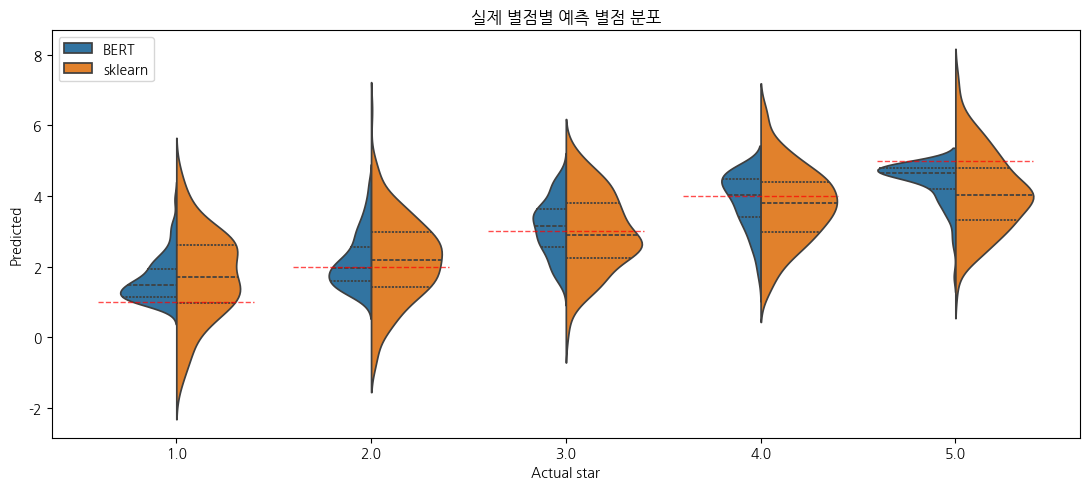

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(
    data=df_compare, x="Actual star", y="Predicted", hue="Model",
    split=True, inner="quart", ax=ax,
)
for i, x_val in enumerate([1, 2, 3, 4, 5]):
    ax.plot([i - 0.4, i + 0.4], [x_val, x_val], "r--", linewidth=1, alpha=0.7)
ax.set_title("실제 별점별 예측 별점 분포")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**무엇이 보이나**

- BERT 쪽 violin이 더 가늘고 빨간 점선 근처에 모이면 같은 actual class 안에서 예측 일관성이 높다는 뜻.
- 두 끝(1점, 5점)에서 분포 중심이 안쪽으로 살짝 치우치는 모양이 자주 보입니다 — 모델이 *중앙 쪽으로 회귀(regression to the mean)* 하는 경향.
- sklearn 쪽 violin이 더 두텁고 길게 늘어진다면 outlier 예측이 많다는 신호.

이 그래프는 "모델이 무엇을 출력하나"의 *raw 분포* 를 봅니다. 다음 그래프는 *오차 자체* 에 집중합니다.

### 시각 2 — 잔차(Residual = Predicted − Actual) 분포 per actual class

`Predicted − Actual` 을 y축에 두고 0 기준선을 긋습니다. 잔차가 0 근처에 좁게 모일수록 정확하고, 양/음 한 쪽으로 치우치면 *bias* 가 있다는 뜻.

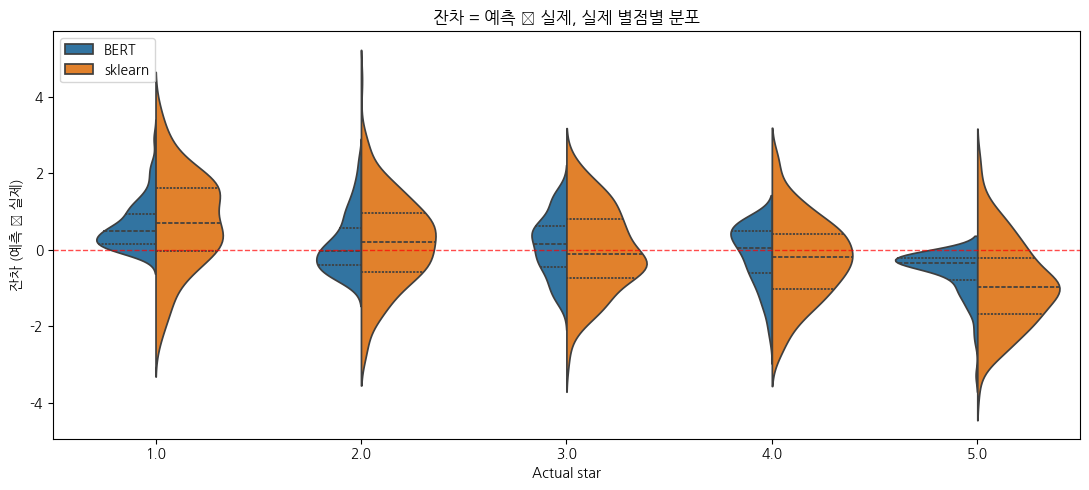

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(
    data=df_compare, x="Actual star", y="Residual", hue="Model",
    split=True, inner="quart", ax=ax,
)
ax.axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("잔차 = 예측 − 실제, 실제 별점별 분포")
ax.set_ylabel("잔차 (예측 − 실제)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**무엇이 보이나**

- 잔차의 *중심* 이 0 위/아래 어디에 있는지가 *bias의 방향*. 1점 class에서 잔차 중심이 +쪽이면 모델이 "1점인데 1점보다 높게" 예측하는 경향이 있다는 뜻.
- 잔차의 *폭* 이 그 class에서의 일반적 오차 크기. BERT가 sklearn보다 좁다면 더 정확.
- 두 끝 class(1점, 5점)에서 잔차 중심이 *반대 방향* (1점은 +, 5점은 −)으로 치우치는 패턴이 자주 보입니다 — 위에서 본 *regression to the mean* 의 잔차 시각화 형태.
- 0 기준선에서 멀리 늘어진 꼬리는 큰 오차를 내는 outlier 샘플들. 어느 모델이 꼬리가 더 두꺼운지 비교.

**두 시각을 함께 보는 이유**: 시각 1은 *모델이 무엇을 출력하나* (raw 분포), 시각 2는 *얼마나 틀렸나* (오차 분포). 같은 데이터의 다른 시점이라 한쪽만 봐서는 놓치는 패턴이 있습니다. 정량 지표(MSE/MAE/R²) 표와 이 두 시각을 함께 읽으면 회귀 평가가 입체적이 됩니다.

## 5. 🛠️ 변형 — 학습이 어디서 망가지는지 (개념만)

직접 다 돌리진 않고 *어떤 인자를 바꾸면 무슨 일이 일어나는지* 짚습니다.

| 바꾸는 인자 | 자주 보는 결과 |
|---|---|
| `num_train_epochs=5` (더 오래) | 학습 loss는 더 줄지만 eval은 정체/악화 (overfitting) |
| `learning_rate=2e-4` (10배 큼) | 학습 초반에 loss가 발산하거나 nan으로 감 |
| `learning_rate=2e-7` (100배 작음) | 학습이 거의 안 됨 (loss가 안 줄어듦) |
| `batch_size=4` | step 수 증가, 학습 시간 길어짐, gradient 잡음 큼 |
| `batch_size=64` | T4에서 OOM 위험 (max_length=128 + DistilBERT는 32까지가 안전) |
| `fp16=False` | VRAM 2배, 속도 느려짐, 결과는 비슷 |
| `max_length=512` | 시퀀스 길이가 4배라 attention 비용 16배 — T4 30분 초과 |

이 표가 BERT 파인튜닝의 *기본 안전대* 입니다. Ch 10 이후 모든 학습 챕터에서도 동일한 인자 범위에서 움직입니다.

## 📦 이번 챕터에 등장한 라이브러리·함수

### `transformers` 학습 도구

| 이름 | 한 줄 설명 | 다음 챕터에서 |
|---|---|---|
| `AutoModelForSequenceClassification.from_pretrained(..., num_labels=1, problem_type="regression")` | 회귀 헤드를 가진 모델 자동 구성 | Ch 10-13에서 num_labels·problem_type만 바꾸어 재사용 |
| `Trainer` | 학습 루프 + 평가 + 로깅 + 체크포인트 자동화 | 모든 Phase 1·2 학습 챕터의 기본 |
| `TrainingArguments` | 학습 하이퍼파라미터 묶음 | num_epochs / batch / lr / fp16 등 인자 동일 |
| `Trainer.train()`, `.evaluate()`, `.predict()` | 학습 / 평가 / 추론 호출 | 모든 학습 챕터 |

### Trainer가 자동으로 해주는 일

- **DataCollatorWithPadding** 생성 (`tokenizer` 인자 보고)
- 학습 루프 (epoch 반복, batch 단위 forward/backward/optimizer step)
- 평가 (`eval_strategy` 에 따라)
- fp16 mixed precision (`fp16=True` 옵션 보고)
- 로깅 (`logging_steps`)
- 체크포인트 (`save_strategy`)
- gradient clipping (기본 1.0)
- learning rate scheduler (기본 linear warmup → linear decay)

### `compute_metrics` 함수 시그니처

```python
def compute_metrics(eval_pred) -> dict:
    preds, labels = eval_pred       # numpy arrays
    return {"metric_name": value, ...}   # 결과는 eval_metric_name 으로 출력
```

## 🎯 체크포인트 질문

1. `num_labels=1` 과 `problem_type="regression"` 두 인자가 `Trainer` 동작에 어떤 영향을 주나요?
2. 학습 중 VRAM이 모델 가중치만 있는 상태보다 더 큰 이유는 무엇인가요? (옵티마이저·gradient·activation)
3. sklearn `LinearRegression` 의 정규방정식과 BERT의 Adam optimizer는 같은 MSE를 최소화하는데도 학습 시간·결정성이 왜 그렇게 다른가요?
4. `compute_metrics` 함수의 입력 `eval_pred` 는 어떤 형태인가요? 회귀와 분류에서 어떻게 달라지나요?

## ❓ FAQ

### Q1. (실무) 학습 중 loss가 nan이 됩니다. 어떻게 하나요?

가장 흔한 원인이 fp16 수치 오버플로우입니다. 해결 순서:

1. `fp16=False` 로 두고 다시 시도. nan이 사라지면 fp16이 원인.
2. 학습률을 낮춥니다 (`learning_rate=1e-5` 또는 `5e-6`).
3. 그래도 안 되면 `gradient_clipping` 을 더 작게 (`max_grad_norm=0.5`).
4. 입력 데이터에 비정상값(빈 문자열, 너무 긴 시퀀스)이 있는지 확인.

T4는 fp16만 지원하고 bf16이 안 됩니다. fp16이 자주 nan을 일으키면 fp32로 가는 게 가장 안전한 fallback입니다.

### Q2. (실무) `Trainer.train()` 한 줄로 GPU 사용률이 낮은데 어떻게 올리나요?

세 가지 흔한 원인.

1. **batch_size가 작음**: T4에서 DistilBERT는 max_length=128, batch_size=32까지 무난. `per_device_train_batch_size` 를 키워보세요.
2. **DataLoader 워커 부족**: `dataloader_num_workers=2` 또는 4로 늘려 CPU에서 토크나이저 처리가 GPU를 기다리지 않게.
3. **`fp16=True` 로 메모리 여유 확보**: 같은 VRAM에 더 큰 batch를 담을 수 있음.

```python
training_args = TrainingArguments(
    ...,
    per_device_train_batch_size=32,
    fp16=True,
    dataloader_num_workers=2,
)
```

### Q3. (실무) 학습 중간에 끊겼는데 이어서 학습하려면?

`save_strategy="epoch"` 으로 체크포인트를 저장해 두면 다음과 같이 이어 학습할 수 있습니다.

```python
trainer.train(resume_from_checkpoint="./output/checkpoint-500")
# 또는 가장 최근 체크포인트 자동 탐지:
trainer.train(resume_from_checkpoint=True)
```

이번 챕터는 학습이 짧아 `save_strategy="no"` 로 두었습니다. Ch 14 같은 긴 학습이나 실무 프로젝트에선 `save_strategy="epoch"` + `save_total_limit=2` 가 표준 패턴입니다.

### Q4. (이론) BERT의 `[CLS]` 토큰이 회귀 출력을 어떻게 만들어내나요?

DistilBERT의 마지막 layer hidden state는 shape `(batch, seq_len, 768)` 입니다. 분류·회귀 헤드는 그중 *첫 번째 토큰* 의 hidden state(`[CLS]` 위치)를 가져와 `Linear(768, num_labels)` 에 통과시킵니다.

```python
# AutoModelForSequenceClassification 내부 (단순화)
hidden_states = self.distilbert(input_ids).last_hidden_state  # (B, L, 768)
cls_hidden = hidden_states[:, 0]                              # (B, 768)
logits = self.classifier(cls_hidden)                          # (B, num_labels)
```

`[CLS]` 위치의 hidden state는 사전학습 단계부터 *전체 문장의 의미를 모으는 자리* 로 학습됐습니다 (attention을 통해). 그래서 분류·회귀 헤드를 `[CLS]` 위치에 붙이는 게 자연스럽고, BERT 표준 관행이 됐습니다.

### Q5. (이론) 사전학습된 BERT를 가져다 쓰는 게 sklearn보다 왜 더 잘 되나요?

세 가지 이유.

1. **단어 독립 가정 탈피**: TF-IDF는 `"not bad"` 와 `"bad"` 를 구분 못 합니다. BERT는 attention으로 `"not"` 과 `"bad"` 의 *조합* 을 학습합니다.
2. **사전학습으로 얻은 일반 지식**: 위키피디아·BookCorpus로 학습한 단어 의미·문법·상식이 본체에 인코딩돼 있고, 우리는 그 위에 task-specific 헤드만 미세 조정.
3. **분포 표현(distributed representation)**: 768차원 hidden state로 단어·문장을 벡터로 표현하니 미묘한 의미 차이도 거리로 잡힘.

다만 *모든* 데이터에서 BERT가 sklearn을 압도하는 건 아닙니다. Yelp 별점은 단어 빈도가 강한 신호라 sklearn도 꽤 잘하고, 데이터가 작거나(수백 건) feature가 명확한 task(분야 키워드 분류)는 sklearn이 BERT보다 빠르고 가성비 좋습니다.

### Q6. (실무) `output_dir` 에 뭐가 저장되나요?

`save_strategy` 가 `"no"` 가 아니면:

- `checkpoint-{step}/` — 모델 가중치, 옵티마이저 상태, scheduler 상태, RNG state (재현 가능한 재개)
- `pytorch_model.bin` 또는 `model.safetensors` — 모델 가중치
- `config.json` — 모델 config (Ch 7 부록 참고)
- `tokenizer.json`, `vocab.txt` 등 — 토크나이저 (`tokenizer=...` 인자가 있을 때)
- `training_args.bin` — 학습 인자 dump
- `trainer_state.json` — loss/metric 로그

Colab에서 `output_dir` 를 Drive 경로로 잡으면 세션이 끊겨도 보존됩니다 (`output_dir="/content/drive/MyDrive/runs/ch09"`).

## 🚀 삽질 코너 (선택)

다음 코드를 돌려보고 어떤 에러가 나는지 보세요.

```python
# label dtype 실수 — 정수로 두고 학습 시도
def tokenize_int(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"] = batch["label"]   # float이 아닌 int!
    return out

train_int = train_ds.select(range(100)).map(tokenize_int, batched=True).remove_columns(["text", "label"])
```

힌트: 회귀 task에서 라벨이 int면 `MSELoss` 가 squared error 계산은 하지만 dtype 경고나 미묘한 문제가 생길 수 있습니다. `problem_type="regression"` 은 라벨이 *float* 이라고 가정합니다. `label2id`/`id2label` 도 자동 안 만들어집니다.

회귀 라벨은 *항상 float* 으로 변환하는 게 안전합니다.

## 다음 챕터 예고

**Chapter 10. BERT Binary 방식 A — sigmoid+BCE**

- Ch 4 (sklearn) 에서 본 동등성의 BERT 버전 시작
- `num_labels=1`, sigmoid, `BCEWithLogitsLoss` 로 Yelp 이진화 학습
- Ch 9의 `Trainer` 골격을 그대로 재사용

**Chapter 11. BERT Binary 방식 B — softmax+CE** 가 그 다음에 이어집니다 (BERT 표준). 두 챕터의 `predict_proba` 가 거의 일치하는지 비교가 핵심.